In [23]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm

In [48]:
import scipy

In [73]:
def f(x,s):
    return x**3*np.exp(-x**2/(2*s**2))
def g(x,s):
    return x**3 * np.sqrt(2*np.pi)

In [231]:
s=1
N=100000
xmax= 3*2*s
xmin= 0
xi=np.random.uniform(xmin,xmax, N)


In [232]:
integral = (xmax - xmin) * np.mean(f(xi, s))
print(integral)

2.008034231623034


In [233]:
#sample half of the gaussian 

In [234]:
distG = scipy.stats.norm(scale=s) 
draws = abs(distG.rvs(1000000)) # random draws

integral = 0.5*s*np.mean(g(draws,s))

print(integral)

1.9969617401634354


In [237]:
integrals = []
integralGs = []
for n in np.arange(10,1000000,10000):
    N=10000
    xi=np.random.uniform(xmin,xmax, n)
    integral = (xmax - xmin) * np.mean(f(xi, s))
    draws = abs(distG.rvs(1000000)) # random draws
    integralG = 0.5*s*np.mean(g(draws,s))
    integrals.append(integral)
    integralGs.append(integralG)
    


[]

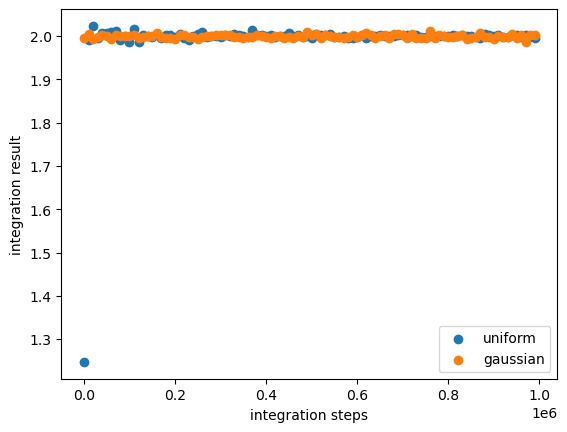

In [243]:
plt.scatter(np.arange(10,1000000,10000),integrals, label='uniform')
plt.scatter(np.arange(10,1000000,10000),integralGs, label='gaussian')
plt.xlabel('integration steps')
plt.ylabel('integration result')
plt.legend()
plt.plot()

In [ ]:
#horse-related deaths

In [249]:
from scipy.stats import poisson

[0.545 0.325 0.11  0.015 0.005]


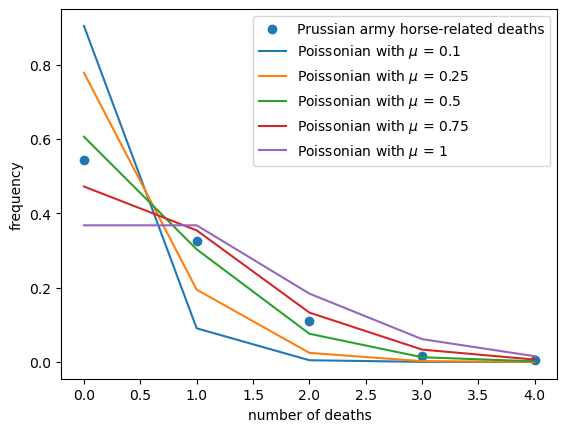

In [273]:
deaths = np.array([0,1,2,3,4])
groups = np.array([109, 65, 22, 3, 1])
death_prob = groups/sum(groups)
print(death_prob)

plt.xlabel('number of deaths')
plt.ylabel('frequency')

plt.scatter(deaths,death_prob,label='Prussian army horse-related deaths')

x = np.arange(0,5)
for mu in [0.1,0.25,0.5,0.75,1]:
    dist = poisson(mu)
    y = dist.pmf(x)
    plt.plot(x,y,label=f'Poissonian with $\mu$ = '+ str(mu))

plt.legend()
plt.show()

[0.54335087 0.33144403 0.10109043 0.02055505 0.00313465]


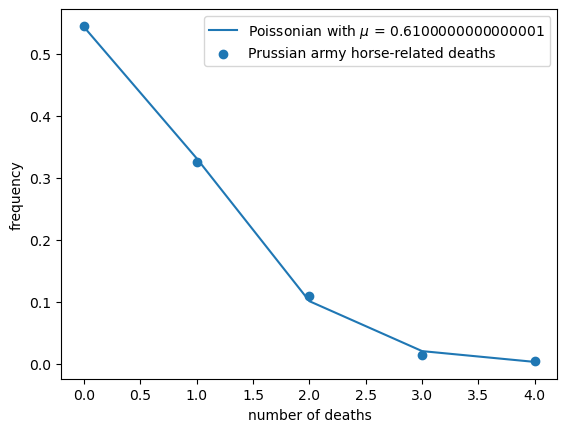

In [279]:
mean = np.average(deaths, weights=death_prob)
y_avg = poisson(mean).pmf(x)
print(y_avg)

plt.plot(x,y_avg,label=f'Poissonian with $\mu$ = '+ str(mean))

plt.xlabel('number of deaths')
plt.ylabel('frequency')

plt.scatter(deaths,death_prob,label='Prussian army horse-related deaths')

plt.legend()
plt.show()